# Palm Club Employee Churn EDA Notebook

## Section 0 - Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Consistent plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

REFERENCE_DATE = pd.Timestamp("2026-03-14")
HIGH_PERF_THRESHOLD = 75    # Will be adjusted after inspecting score distribution

## Section 1 - Data Loading & Inspection

In [ ]:
emp = pd.read_csv("data/BOLT_Employees.csv")
applicant = pd.read_csv("data/BOLT_Applicants.csv")
changes = pd.read_csv("data/BOLT_EmployeeChanges.csv")
perf = pd.read_csv("data/BOLT_Performance.csv")
branch = pd.read_csv("data/BOLT_Branch.csv")

In [6]:
for df in [emp, applicant, changes, perf, branch]:
    df.shape
    df.info()
    df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   EmployeeID            1067 non-null   int64  
 1   Wage                  1067 non-null   str    
 2   HiredOn               1067 non-null   str    
 3   Branch#               1067 non-null   int64  
 4   Current status        1067 non-null   str    
 5   Position              1067 non-null   str    
 6   Role                  1067 non-null   str    
 7   AvgWorkingHours/Week  1067 non-null   float64
 8   ApplicantID           1067 non-null   int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 75.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   ApplicantID                10500 non-null  int64
 1   PastRelevantExperienc

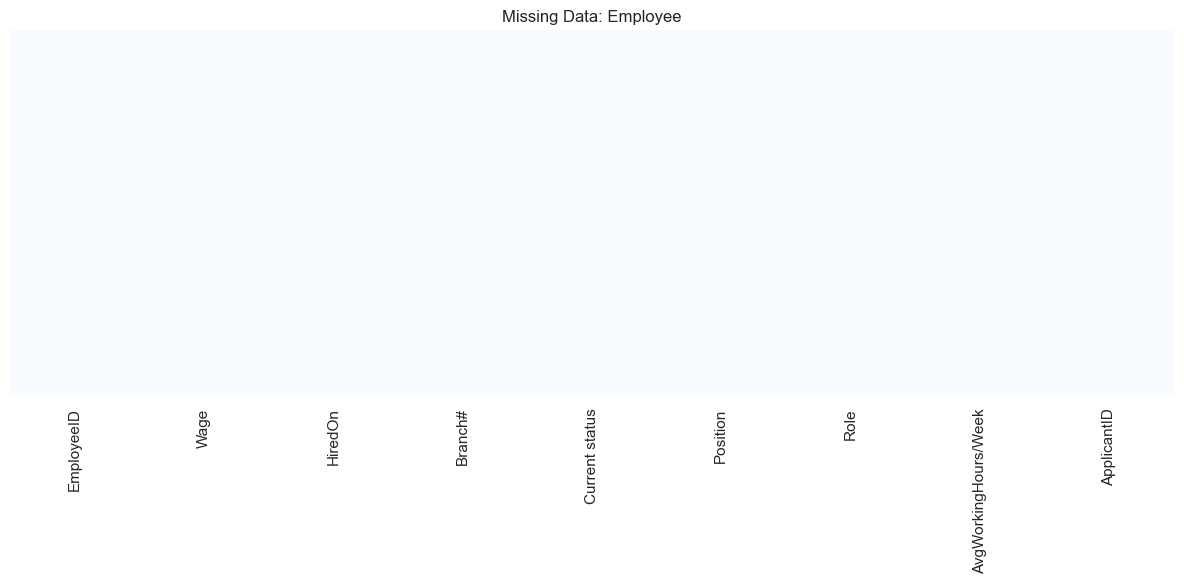

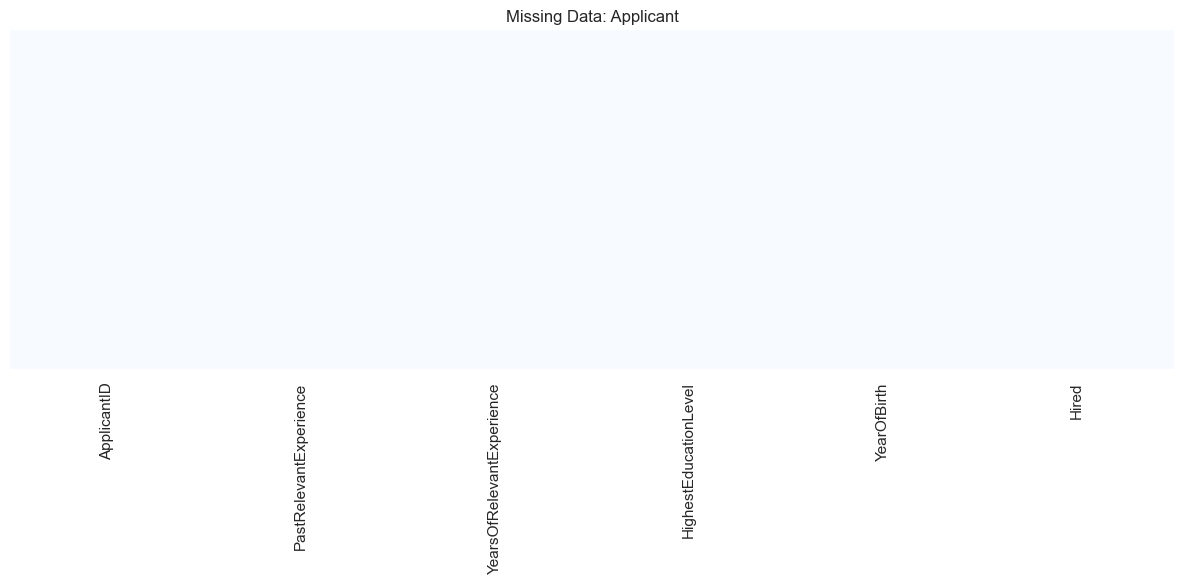

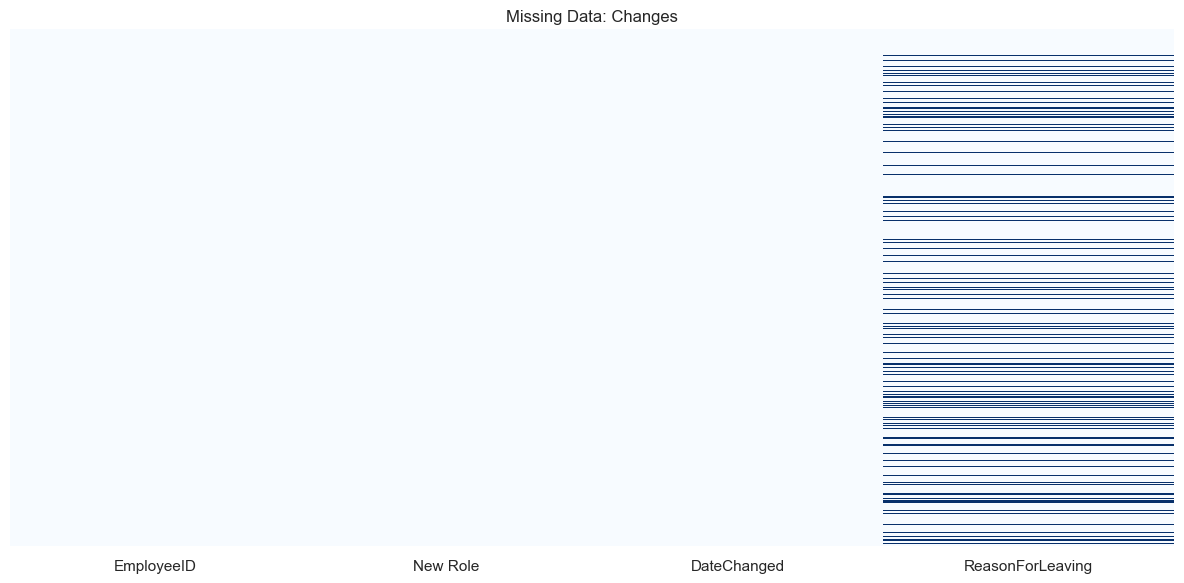

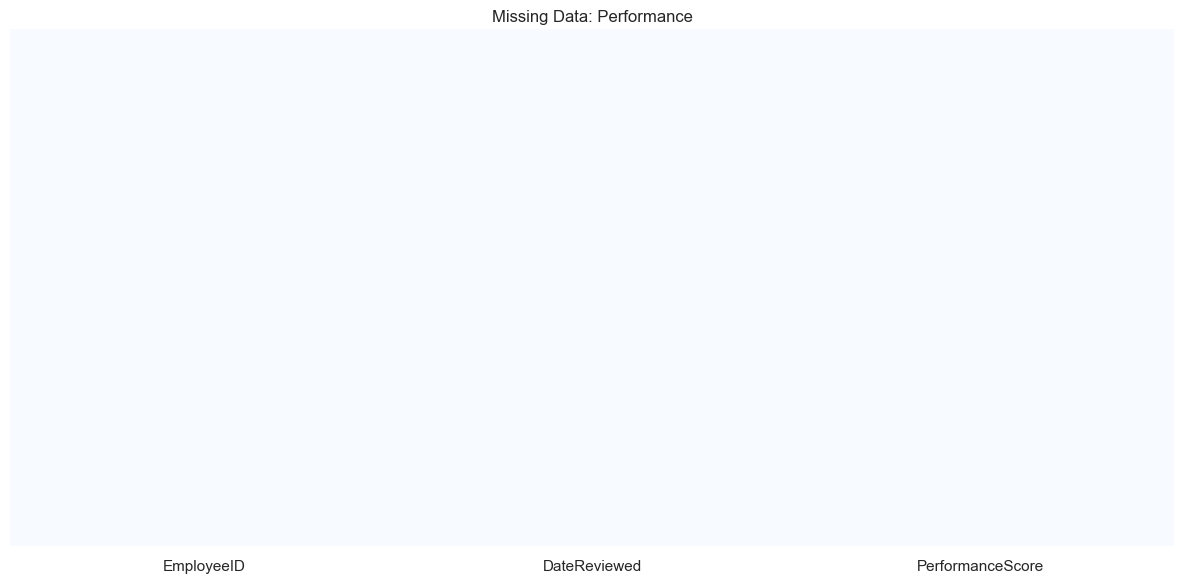

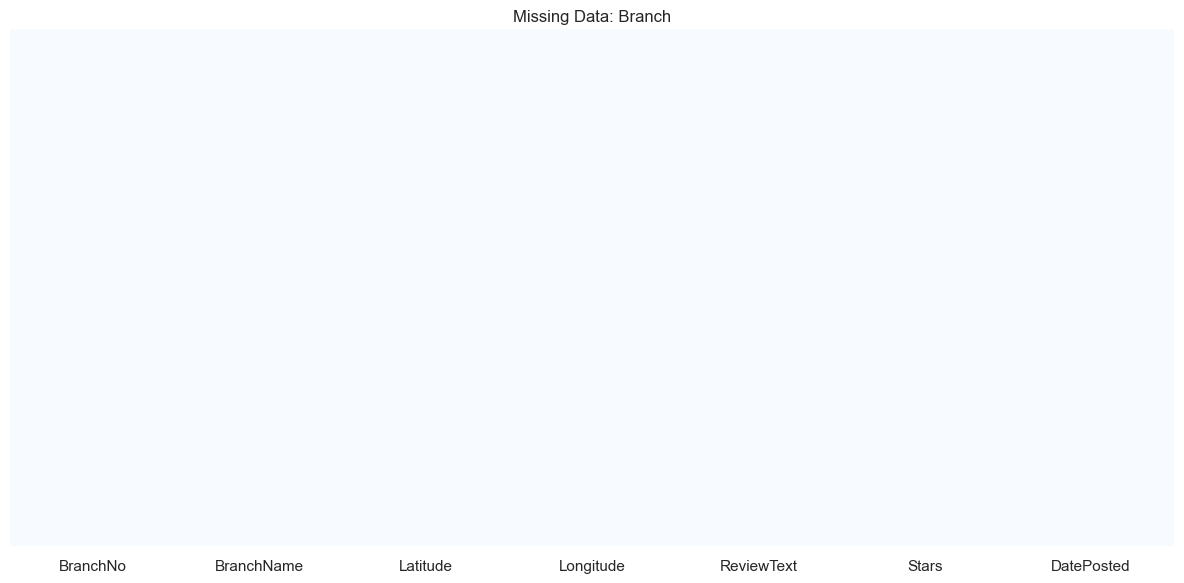

In [13]:
# Missing data heatmaps
for name, df in {
    "Employee": emp,
    "Applicant": applicant,
    "Changes": changes,
    "Performance": perf,
    "Branch": branch,
}.items():
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="Blues")
    plt.title(f"Missing Data: {name}")
    plt.tight_layout()
    plt.show()

## Section 2 - Data Cleaning

In [ ]:
# Parse dates
emp["HiredOn"] = pd.to_datetime(emp["HiredOn"])
changes["DateChanged"] = pd.to_datetime(changes["DateChanged"])
perf["DateReviewed"] = pd.to_datetime(perf["DateReviewed"])
branch["DatePosted"] = pd.to_datetime(branch["DatePosted"])

Derive Tenure (days employed)

In [19]:
print(changes["New Role"].unique())

<StringArray>
[            'Quit',        'Dismissed',        'Bartender',
           'Server',          'Manager', 'Server Assistant',
       'Shift Lead']
Length: 7, dtype: str


In [23]:

# For active employees, tenure runs to today
# For exited employees, tenure runs to their exit date

exit_dates = (
    changes[changes["New Role"].isin(["Quit", "Dismissed"])]
    .groupby("EmployeeID")["DateChanged"].max()
    .rename("ExitDate")
)

employee = emp.merge(exit_dates, on="EmployeeID", how="left")
employee["EndDate"] = employee["ExitDate"].fillna(REFERENCE_DATE)
employee["TenureDays"] = (employee["EndDate"] - employee["HiredOn"]).dt.days
employee["TenureMonths"] = employee["TenureDays"] / 30.44

print(employee.head())

   EmployeeID         Wage    HiredOn  Branch# Current status   Position  \
0        5764      Minimum 2022-06-13        1        Working  full-time   
1        5997      Minimum 2024-02-26        1        Working  full-time   
2        5454  Competitive 2024-06-20        1        Working  full-time   
3        5557  Competitive 2024-09-04        1        Working  full-time   
4        5923      Minimum 2024-12-07        1        Working  full-time   

      Role  AvgWorkingHours/Week  ApplicantID ExitDate    EndDate  TenureDays  \
0  Manager                  48.8       107642      NaT 2026-03-14        1370   
1  Manager                  50.4       109966      NaT 2026-03-14         747   
2  Manager                  49.2       104693      NaT 2026-03-14         632   
3  Manager                  52.0       105628      NaT 2026-03-14         556   
4  Manager                  48.6       109352      NaT 2026-03-14         462   

   TenureMonths  
0     45.006570  
1     24.540079  
2 

Identify Exits vs. Promotions